In [1]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)


print("Libraries loaded.")

Libraries loaded.


In [2]:
DATA_PATH = (
    Path("../datasets")
    / "diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
)

df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

(70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth              70692 no

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


In [5]:
df["Diabetes_binary"].value_counts()

Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64

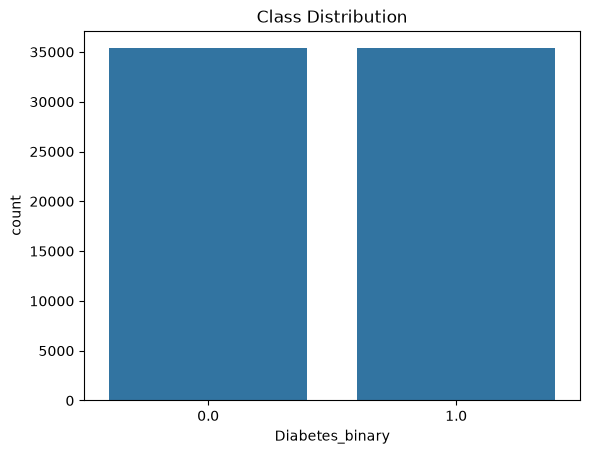

In [6]:
sns.countplot(
    x="Diabetes_binary",
    data=df
)

plt.title("Class Distribution")

plt.show()

In [7]:
correlation = (
    df.corr()["Diabetes_binary"]
      .sort_values(ascending=False)
)

correlation

Diabetes_binary         1.000000
GenHlth                 0.407612
HighBP                  0.381516
BMI                     0.293373
HighChol                0.289213
Age                     0.278738
DiffWalk                0.272646
PhysHlth                0.213081
HeartDiseaseorAttack    0.211523
Stroke                  0.125427
CholCheck               0.115382
MentHlth                0.087029
Smoker                  0.085999
Sex                     0.044413
NoDocbcCost             0.040977
AnyHealthcare           0.023191
Fruits                 -0.054077
Veggies                -0.079293
HvyAlcoholConsump      -0.094853
PhysActivity           -0.158666
Education              -0.170481
Income                 -0.224449
Name: Diabetes_binary, dtype: float64

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop("Diabetes_binary", axis=1)

y = df["Diabetes_binary"]

(
    X_train,
    X_test,
    y_train,
    y_test
) = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

print(X_train.shape)

print(X_test.shape)

(56553, 21)
(14139, 21)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(
    X_train_scaled,
    y_train
)

pred = lr.predict(
    X_test_scaled
)

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))

Accuracy : 0.7458094631869298
Precision: 0.7372013651877133
Recall   : 0.7638987126892064
F1 Score : 0.7503126302626094


## importing all model

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd

## Creating Model Dictionary

In [12]:
models = {

    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        n_estimators=200
    )

}

## training all models

In [13]:
# ==========================================
# TRAIN AND EVALUATE ALL MODELS
# ==========================================

results = []

trained_models = {}

for name, model in models.items():

    print("\n" + "=" * 70)
    print(f"Training: {name}")
    print("=" * 70)

    # Logistic Regression uses scaled data
    if name == "Logistic Regression":

        model.fit(
            X_train_scaled,
            y_train
        )

        predictions = model.predict(
            X_test_scaled
        )

        probabilities = model.predict_proba(
            X_test_scaled
        )[:, 1]

    else:

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_test
        )

        probabilities = model.predict_proba(
            X_test
        )[:, 1]

    trained_models[name] = model

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    results.append({

        "Model": name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)

    })

    print(f"✓ {name} completed successfully.")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")


Training: Logistic Regression
✓ Logistic Regression completed successfully.
Accuracy : 0.7458
F1 Score : 0.7503
ROC-AUC  : 0.8232

Training: Decision Tree
✓ Decision Tree completed successfully.
Accuracy : 0.6513
F1 Score : 0.6468
ROC-AUC  : 0.6515

Training: Random Forest
✓ Random Forest completed successfully.
Accuracy : 0.7358
F1 Score : 0.7451
ROC-AUC  : 0.8120

Training: XGBoost
✓ XGBoost completed successfully.
Accuracy : 0.7503
F1 Score : 0.7611
ROC-AUC  : 0.8285

Training: LightGBM
[LightGBM] [Info] Number of positive: 28277, number of negative: 28276
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010821 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 197
[LightGBM] [Info] Number of data points in the train set: 56553, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500009 -> initscore=0.000035
[L

## Compare Results

In [14]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,LightGBM,0.7522,0.7304,0.7993,0.7633,0.8305
3,XGBoost,0.7503,0.7295,0.7956,0.7611,0.8285
0,Logistic Regression,0.7458,0.7372,0.7639,0.7503,0.8232
2,Random Forest,0.7358,0.7199,0.7721,0.7451,0.8120
1,Decision Tree,0.6513,0.6552,0.6386,0.6468,0.6515


In [15]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LightGBM,0.7522,0.7304,0.7993,0.7633,0.8305
1,XGBoost,0.7503,0.7295,0.7956,0.7611,0.8285
2,Logistic Regression,0.7458,0.7372,0.7639,0.7503,0.8232
3,Random Forest,0.7358,0.7199,0.7721,0.7451,0.8120
4,Decision Tree,0.6513,0.6552,0.6386,0.6468,0.6515


## Best Model

In [16]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print(f"Best Model: {best_model_name}")

Best Model: LightGBM


## Detailed Report

In [17]:
if best_model_name == "Logistic Regression":

    predictions = best_model.predict(
        X_test_scaled
    )

else:

    predictions = best_model.predict(
        X_test
    )

print(classification_report(
    y_test,
    predictions
))

print(confusion_matrix(
    y_test,
    predictions
))

              precision    recall  f1-score   support

         0.0       0.78      0.71      0.74      7070
         1.0       0.73      0.80      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139

[[4985 2085]
 [1419 5650]]


## save models

In [18]:
import joblib
from pathlib import Path

# Create models directory
Path("../models").mkdir(exist_ok=True)

# Save best model
joblib.dump(
    trained_models["LightGBM"],
    "../models/lightgbm_baseline.pkl"
)

# Save scaler
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Baseline model saved successfully.")

Baseline model saved successfully.


# tuning LightGBM

In [19]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

import pandas as pd

## Define the Parameter Space

In [20]:
param_grid = {

    "n_estimators": [100, 200, 300, 500],

    "learning_rate": [0.01, 0.05, 0.1, 0.2],

    "num_leaves": [20, 31, 40, 50, 70],

    "max_depth": [-1, 5, 10, 15],

    "min_child_samples": [10, 20, 30, 50],

    "subsample": [0.8, 0.9, 1.0],

    "colsample_bytree": [0.8, 0.9, 1.0]

}

## Creating  the Base Model

In [21]:
lgbm = LGBMClassifier(
    random_state=42
)

## Configure Random Search

In [22]:
random_search = RandomizedSearchCV(

    estimator=lgbm,

    param_distributions=param_grid,

    n_iter=20,

    scoring="roc_auc",

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=-1

)

## training the search

In [23]:
random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 28277, number of negative: 28276
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010103 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 197
[LightGBM] [Info] Number of data points in the train set: 56553, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500009 -> initscore=0.000035
[LightGBM] [Info] Start training from score 0.000035


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [-1, 5, ...], 'min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a functio

In [24]:
print(random_search.best_params_)

{'subsample': 0.9, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': 15, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


## Evaluate the Tuned Model

In [25]:
best_lgbm = random_search.best_estimator_

predictions = best_lgbm.predict(X_test)

probabilities = best_lgbm.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, predictions)

precision = precision_score(
    y_test,
    predictions
)

recall = recall_score(
    y_test,
    predictions
)

f1 = f1_score(
    y_test,
    predictions
)

roc_auc = roc_auc_score(
    y_test,
    probabilities
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.7520
Precision: 0.7302
Recall   : 0.7994
F1 Score : 0.7632
ROC-AUC  : 0.8304


## Saving the Optimized Model

In [26]:
import joblib
from pathlib import Path

Path("../models").mkdir(exist_ok=True)

joblib.dump(
    best_lgbm,
    "../models/lightgbm_best.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Optimized model saved successfully!")

Optimized model saved successfully!


## Feature Importance

In [27]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_lgbm.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,BMI,2717
18,Age,2404
13,GenHlth,2021
20,Income,1107
17,Sex,784
1,HighChol,763
10,HvyAlcoholConsump,648
2,CholCheck,627
6,HeartDiseaseorAttack,615
14,MentHlth,573


## Visualizing Feature Importance

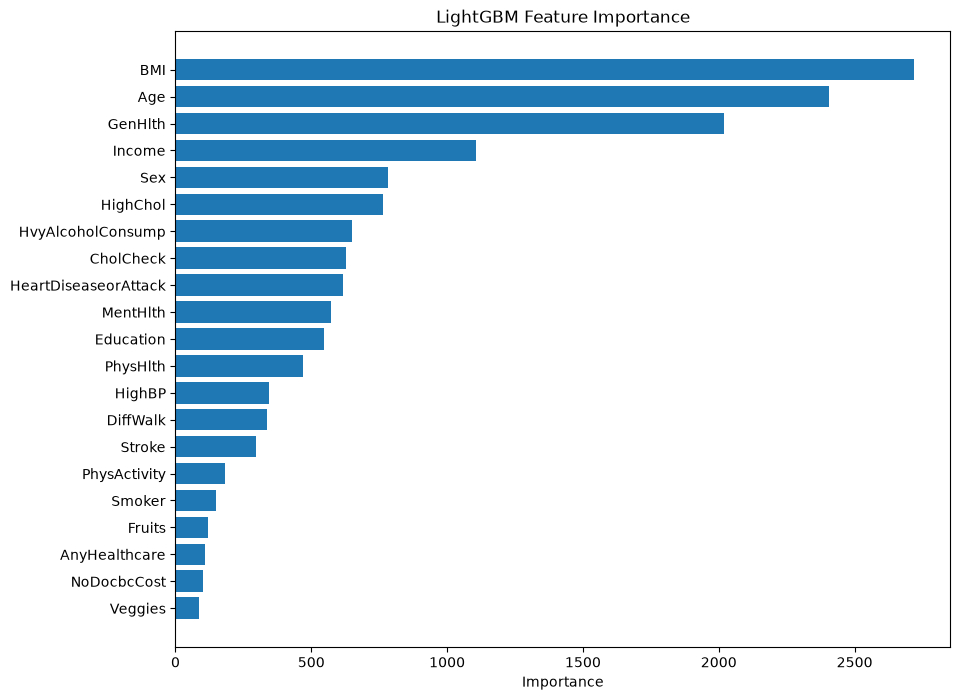

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("LightGBM Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

## it ends her

## Diabetes Class Distribution (Binary)

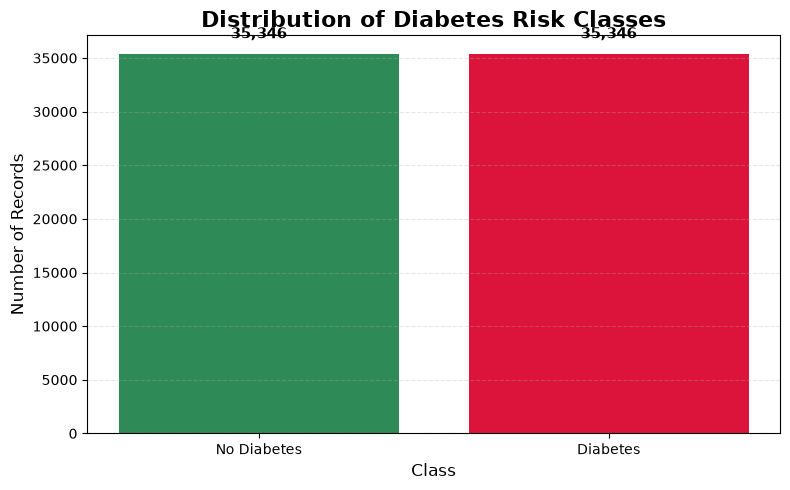

In [33]:
import matplotlib.pyplot as plt

# Count the classes
class_counts = df["Diabetes_binary"].value_counts().sort_index()

# Create chart
plt.figure(figsize=(8, 5))

bars = plt.bar(
    ["No Diabetes", "Diabetes"],
    class_counts.values,
    color=["#2E8B57", "#DC143C"]
)

plt.title(
    "Distribution of Diabetes Risk Classes",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Class", fontsize=12)

plt.ylabel("Number of Records", fontsize=12)

# Add values above bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1500,
        f"{int(bar.get_height()):,}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "diabetes_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Correlation Heatmap

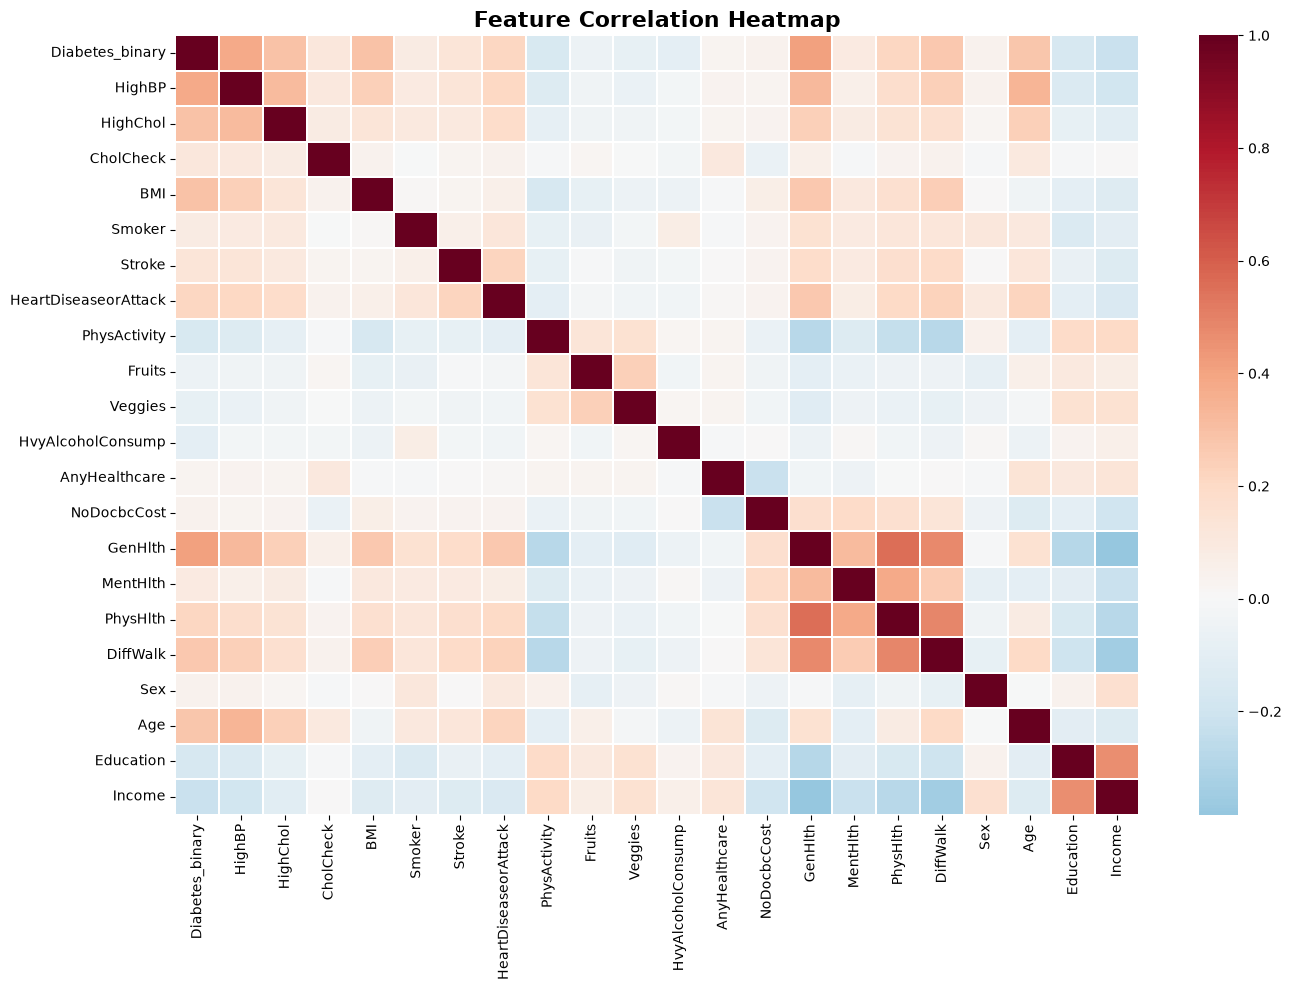

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap="RdBu_r",
    center=0,
    linewidths=0.2
)

plt.title(
    "Feature Correlation Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Model Accuracy Comparison

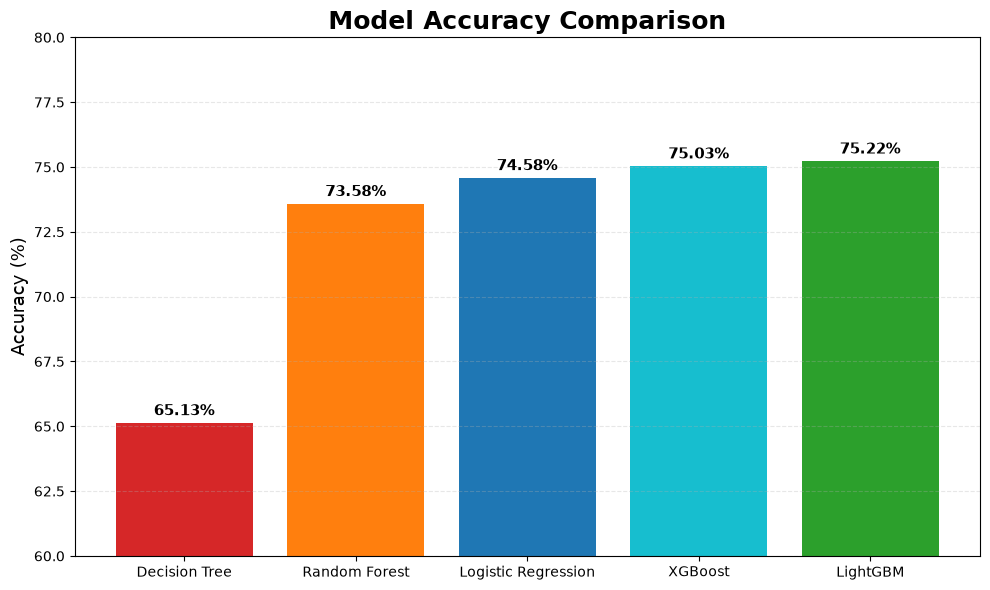

In [35]:
import matplotlib.pyplot as plt

models = [
    "Decision Tree",
    "Random Forest",
    "Logistic Regression",
    "XGBoost",
    "LightGBM"
]

accuracy = [
    65.13,
    73.58,
    74.58,
    75.03,
    75.22
]

colors = [
    "#d62728",
    "#ff7f0e",
    "#1f77b4",
    "#17becf",
    "#2ca02c"
]

plt.figure(figsize=(10,6))

bars = plt.bar(
    models,
    accuracy,
    color=colors
)

plt.title(
    "Model Accuracy Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel("Accuracy (%)", fontsize=13)

plt.ylim(60, 80)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.3,
        f"{bar.get_height():.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## ROC-AUC Comparison

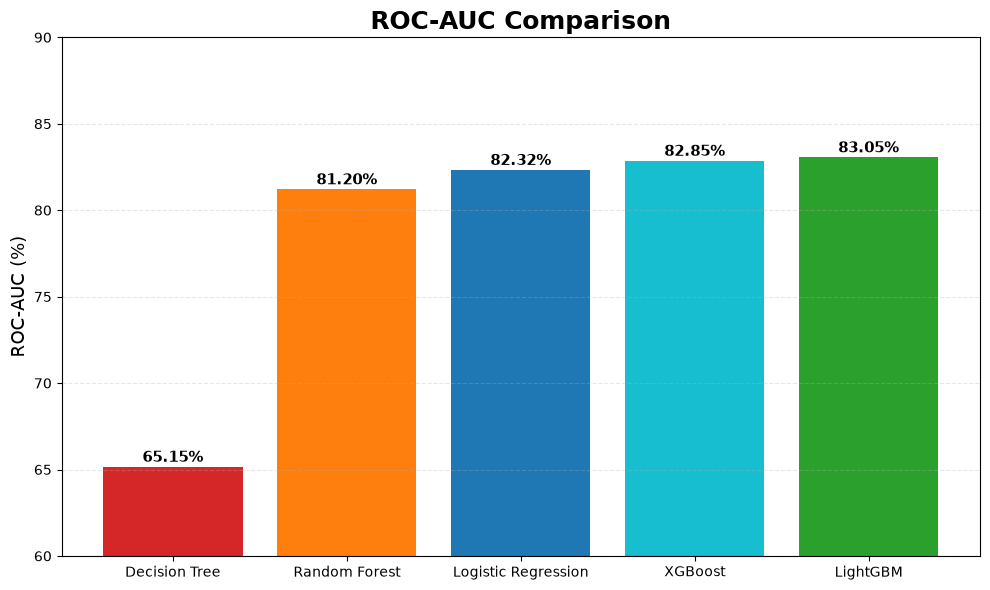

In [36]:
import matplotlib.pyplot as plt

models = [
    "Decision Tree",
    "Random Forest",
    "Logistic Regression",
    "XGBoost",
    "LightGBM"
]

roc_auc = [
    65.15,
    81.20,
    82.32,
    82.85,
    83.05
]

colors = [
    "#d62728",
    "#ff7f0e",
    "#1f77b4",
    "#17becf",
    "#2ca02c"
]

plt.figure(figsize=(10,6))

bars = plt.bar(
    models,
    roc_auc,
    color=colors
)

plt.title(
    "ROC-AUC Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel("ROC-AUC (%)", fontsize=13)

plt.ylim(60,90)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.3,
        f"{bar.get_height():.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "roc_auc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Confusion Matrix (LightGBM)

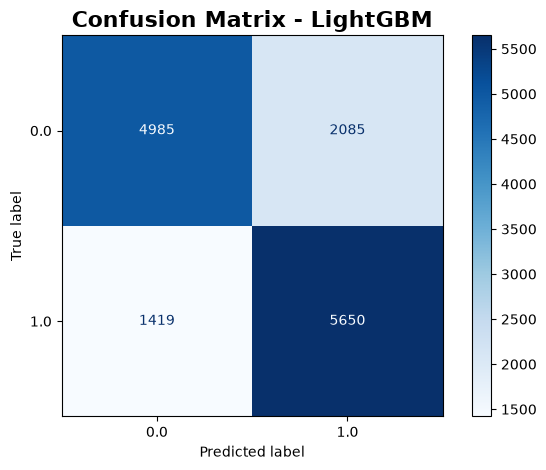

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = trained_models["LightGBM"]

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title(
    "Confusion Matrix - LightGBM",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "lightgbm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## ROC Curve

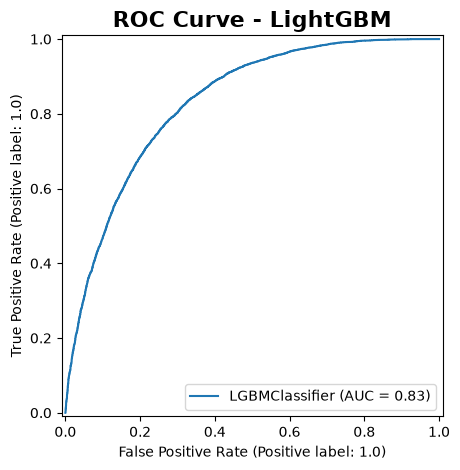

In [38]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title(
    "ROC Curve - LightGBM",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "lightgbm_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Feature Importance

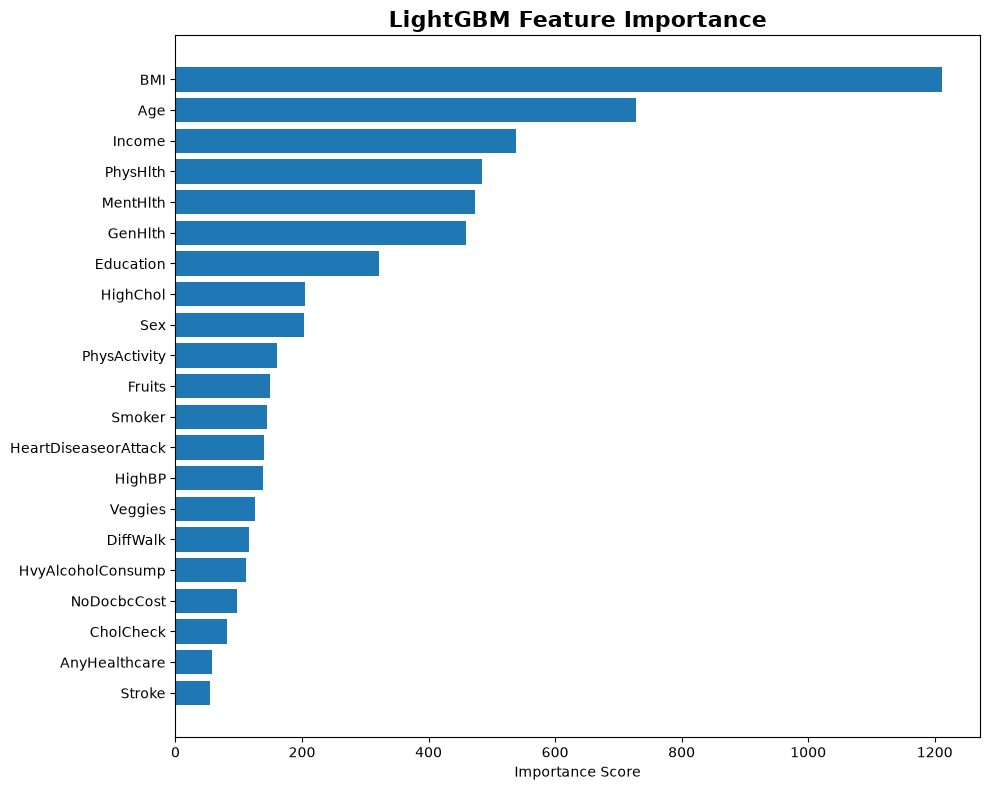

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "LightGBM Feature Importance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance Score")

plt.tight_layout()

plt.savefig(
    "lightgbm_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

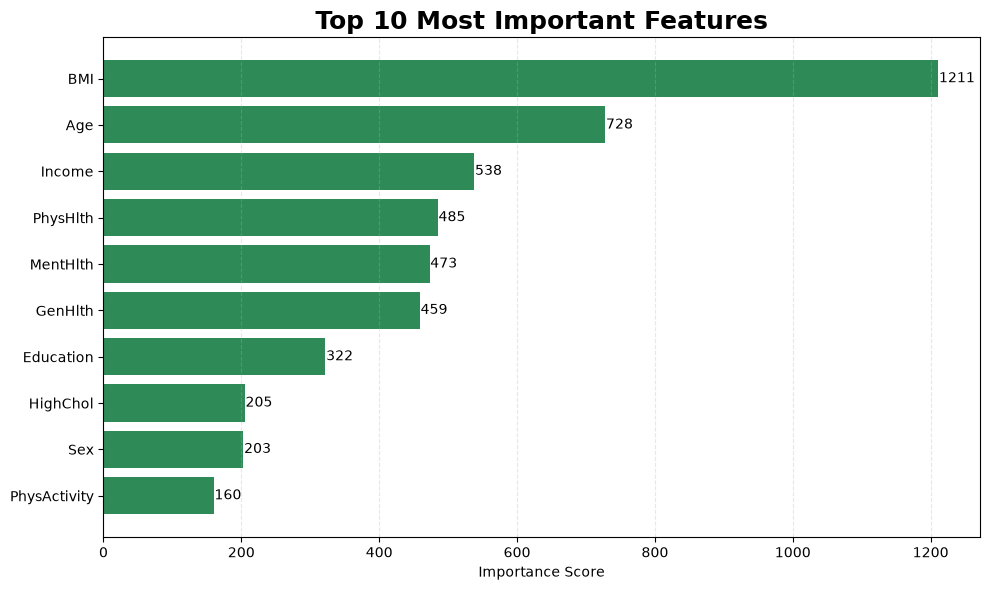

,Feature,Importance
3,BMI,1211
18,Age,728
20,Income,538
15,PhysHlth,485
14,MentHlth,473
13,GenHlth,459
19,Education,322
1,HighChol,205
17,Sex,203
7,PhysActivity,160


In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Best trained model
best_model = trained_models["LightGBM"]

# Create feature importance dataframe
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Keep only Top 10
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color="#2E8B57"
)

plt.gca().invert_yaxis()

plt.title(
    "Top 10 Most Important Features",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Importance Score")

# Add values beside each bar
for bar in bars:
    plt.text(
        bar.get_width()+1,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.0f}",
        va="center",
        fontsize=10
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

importance_df.head(10)